### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### Loading Dataset

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


### Pre-Processing

1) scale: from 0-255 to 0-1
2) reshape: (28,28,1) explicit channel dimension

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


### Introducing Noise to Images

- adding simple Gaussian noise to each image

In [4]:
noise_factor = 0.4

def add_noise(images, noise_factor=noise_factor):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy.astype("float32")

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy train shape:", x_train_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)


### Clean vs Noisy Visualisation

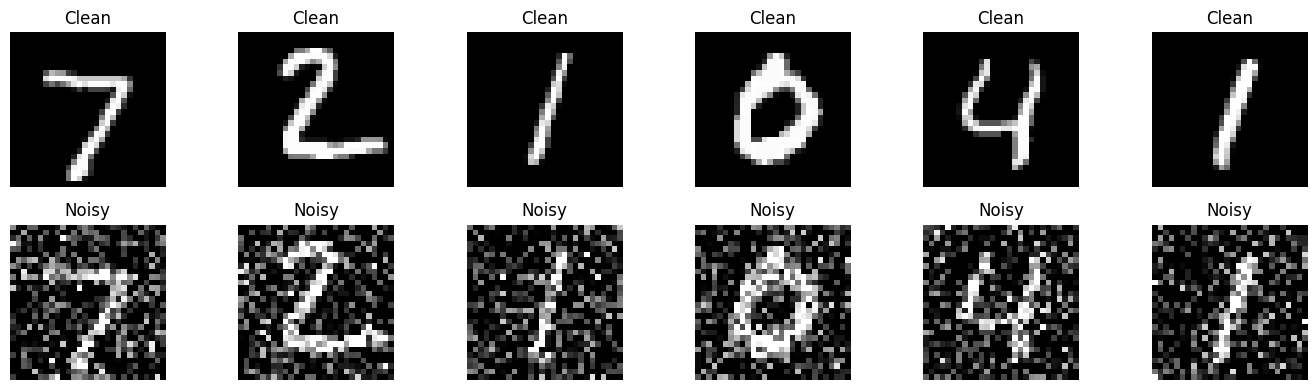

In [7]:
n = 6
plt.figure(figsize=(14, 4))
for i in range(n):
    # Clean
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Autoencoder

- **Encoder:** progressively downsamples the image (Conv2D + MaxPooling) into a compressed representation.
- **Decoder:** progressively upsamples that representation (Conv2D + UpSampling) back to the original `28x28x1` shape.

The final layer uses a `sigmoid` activation since our pixel values are normalized to `[0, 1]`.

In [8]:
def build_autoencoder():
    inputs = layers.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)          # 28x28 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)    # 14x14 -> 7x7

    # Decoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)                          # 7x7 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)                          # 14x14 -> 28x28
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = models.Model(inputs, decoded, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model

- Loss: Binary Cross entropy
- Optimizer: Adam

In [10]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

### Training

In [11]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 0.1444 - val_loss: 0.1018
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0990 - val_loss: 0.0951
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0944 - val_loss: 0.0922
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0921 - val_loss: 0.0905
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0906 - val_loss: 0.0894
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0896 - val_loss: 0.0885
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0889 - val_loss: 0.0879
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0883 - val_loss: 0.0874
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0878 - val_loss: 0.0871
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0874 - val_loss: 0.0867
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0870 - val_loss: 0.0862
Epoch 12/20
469/469 ━━━━━━━━━━

### Training Curves

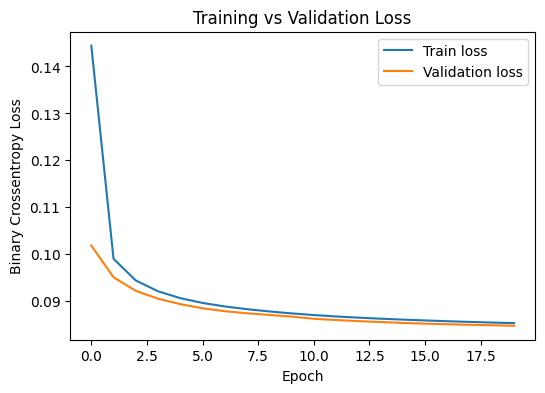

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()